In [1]:
import pandas as pd
import os
import shutil

In [2]:
df = pd.read_csv(r"C:\Users\hp\Desktop\download_log_megabatch_200k-new.csv")
df.head()


,id,filename,keyword_source,original_url,extension,safe
0,1,1.jpg,safe,https://wallpapers.com/images/hd/country-road-...,jpg,0.0
1,2,2.jpg,safe,https://wallpapers.com/images/hd/country-road-...,jpg,0.0
2,3,3.jpg,safe,https://wallpapercave.com/wp/wp2364206.jpg,jpg,0.0
3,4,4.jpg,safe,https://st.depositphotos.com/1669366/1389/i/95...,jpg,0.0
4,5,5.jpg,safe,https://images.freeimages.com/images/large-pre...,jpg,0.0


In [3]:
df.columns


Index(['id', 'filename', 'keyword_source', 'original_url', 'extension',
       'safe'],
      dtype='object')

In [4]:
nsfw_keywords = ["obscene"]


In [5]:
def assign_label(keyword):
    keyword = str(keyword).lower()
    for word in nsfw_keywords:
        if word in keyword:
            return "obscene"
    return "safe"


In [6]:
df["label"] = df["keyword_source"].apply(assign_label)


In [7]:
df["label"].value_counts()


label
safe       100592
obscene      5157
Name: count, dtype: int64

In [8]:
base_dir = "dataset"

folders = [
    "safe",
    "obscene"
]

for folder in folders:
    os.makedirs(os.path.join(base_dir, folder), exist_ok=True)


In [9]:
image_folder = "New Folder"

for _, row in df.iterrows():
    img_name = row["filename"]
    label = row["label"]

    src = os.path.join(image_folder, img_name)
    dst = os.path.join(base_dir, label, img_name)

    if os.path.exists(src):
        shutil.copy(src, dst)


In [10]:
import os

os.listdir("dataset")


['obscene',
 'obscene_1500',
 'obscene_5000',
 'safe',
 'safe_1500',
 'safe_5000',
 'test',
 'train',
 'val']

In [11]:
os.listdir()


['.ipynb_checkpoints',
 'archive (1).zip',
 'cnn_obscene_model.h5',
 'cnn_obscene_model.keras',
 'cnn_obscene_model_DEPLOY.h5',
 'cnn_obscene_model_FINAL.h5',
 'cnn_obscene_model_tf.keras',
 'dataset',
 'dataset_preparation.ipynb',
 'final_gui.py',
 'gui_with_preview.py',
 'New folder',
 'obscene_detect_10000.ipynb',
 'test_image',
 'Untitled-1.txt',
 'uploaded_images',
 'venv']

In [12]:
#after cleaning and checking mistakes manually in both obscene and safe folder

In [13]:
import os

print("Safe images:", len(os.listdir("dataset/safe")))
print("Obscene images:", len(os.listdir("dataset/obscene")))

Safe images: 11707
Obscene images: 5022


In [14]:
#create a separate folder for only 5000 images from both safe and obscene folder

In [15]:
import os
import random
import shutil

random.seed(42)

BASE_DIR = "dataset"
TARGET = 5000

for class_name in ["safe", "obscene"]:
    src_dir = os.path.join(BASE_DIR, class_name)
    images = os.listdir(src_dir)

    print(f"{class_name} available:", len(images))

    selected = random.sample(images, TARGET)

    target_dir = os.path.join(BASE_DIR, f"{class_name}_5000")
    os.makedirs(target_dir, exist_ok=True)

    for img in selected:
        shutil.copy(
            os.path.join(src_dir, img),
            os.path.join(target_dir, img)
        )

    print(f"✅ {class_name}: selected 5000 images")


safe available: 11707
✅ safe: selected 5000 images
obscene available: 5022
✅ obscene: selected 5000 images


In [16]:
len(os.listdir("dataset/safe_5000"))
len(os.listdir("dataset/obscene_5000"))

5102

In [17]:
#Split 10000 images into Train / Val / Test

In [18]:
import os
import random
import shutil

def split_data(class_name):
    src = os.path.join("dataset", f"{class_name}_5000")
    imgs = os.listdir(src)
    random.shuffle(imgs)

   #train = imgs[:1050]     # 70%
    train = imgs[:3500]     # 70%
   #val   = imgs[1050:1275] # 15%
    val   = imgs[3500:4250] # 15%
   #test  = imgs[1275:]     # 15%
    test  = imgs[4250:5000]     # 15%

    for split, data in zip(["train", "val", "test"], [train, val, test]):
        dst = os.path.join("dataset", split, class_name)
        os.makedirs(dst, exist_ok=True)

        for img in data:
            shutil.copy(
                os.path.join(src, img),
                os.path.join(dst, img)
            )

    print(f"{class_name} → train:{len(train)}, val:{len(val)}, test:{len(test)}")

split_data("safe")
split_data("obscene")


safe → train:3500, val:750, test:750
obscene → train:3500, val:750, test:750


In [19]:
#verify counts

In [20]:
print("Train Safe:", len(os.listdir("dataset/train/safe")))
print("Train Obscene:", len(os.listdir("dataset/train/obscene")))

print("Val Safe:", len(os.listdir("dataset/val/safe")))
print("Val Obscene:", len(os.listdir("dataset/val/obscene")))

print("Test Safe:", len(os.listdir("dataset/test/safe")))
print("Test Obscene:", len(os.listdir("dataset/test/obscene")))


Train Safe: 6065
Train Obscene: 4867
Val Safe: 1625
Val Obscene: 1977
Test Safe: 4764
Test Obscene: 2008


In [21]:
import os

for split in ["train", "val", "test"]:
    print(split,
          "safe:", len(os.listdir(f"dataset/{split}/safe")),
          "obscene:", len(os.listdir(f"dataset/{split}/obscene")))

train safe: 6065 obscene: 4867
val safe: 1625 obscene: 1977
test safe: 4764 obscene: 2008


In [22]:
#Model Creation


In [23]:
#Import Libraries

In [24]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
import matplotlib.pyplot as plt


In [25]:
#Define Hyperparameters

In [26]:
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 25


In [27]:
#Image preprocessing & augmentation

#This helps prevent overfitting

In [28]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)


In [29]:
#Load data into CNN

In [30]:
train_data = train_datagen.flow_from_directory(
    "dataset/train",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary"
)

val_data = val_datagen.flow_from_directory(
    "dataset/val",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary"
)

test_data = test_datagen.flow_from_directory(
    "dataset/test",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)


Found 10707 images belonging to 2 classes.
Found 3511 images belonging to 2 classes.
Found 6650 images belonging to 2 classes.


In [31]:
#Confirm class labels

In [32]:
train_data.class_indices


{'obscene': 0, 'safe': 1}

In [33]:
#Build CNN model

In [34]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(1, activation='sigmoid')
])


C:\Users\hp\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [35]:
#Compile the model

In [36]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


In [37]:
#Model summary (check architecture)

In [38]:
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [39]:
#Train the model


In [40]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=25
)


Epoch 1/25


C:\Users\hp\anaconda3\Lib\site-packages\PIL\Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


 30/335 ━━━━━━━━━━━━━━━━━━━━ 31:51 6s/step - accuracy: 0.5487 - loss: 1.1643

C:\Users\hp\anaconda3\Lib\site-packages\PIL\TiffImagePlugin.py:949: UserWarning: Corrupt EXIF data.  Expecting to read 2 bytes but only got 0. 
  warnings.warn(str(msg))


335/335 ━━━━━━━━━━━━━━━━━━━━ 2554s 8s/step - accuracy: 0.8009 - loss: 0.4539 - val_accuracy: 0.8103 - val_loss: 0.4178
Epoch 2/25
335/335 ━━━━━━━━━━━━━━━━━━━━ 1513s 5s/step - accuracy: 0.8518 - loss: 0.3591 - val_accuracy: 0.8405 - val_loss: 0.3745
Epoch 3/25
335/335 ━━━━━━━━━━━━━━━━━━━━ 1410s 4s/step - accuracy: 0.8527 - loss: 0.3484 - val_accuracy: 0.8525 - val_loss: 0.3413
Epoch 4/25
335/335 ━━━━━━━━━━━━━━━━━━━━ 3291s 10s/step - accuracy: 0.8608 - loss: 0.3275 - val_accuracy: 0.8508 - val_loss: 0.3637
Epoch 5/25
335/335 ━━━━━━━━━━━━━━━━━━━━ 1322s 4s/step - accuracy: 0.8630 - loss: 0.3272 - val_accuracy: 0.8234 - val_loss: 0.4206
Epoch 6/25
335/335 ━━━━━━━━━━━━━━━━━━━━ 1321s 4s/step - accuracy: 0.8681 - loss: 0.3189 - val_accuracy: 0.8317 - val_loss: 0.3916
Epoch 7/25
335/335 ━━━━━━━━━━━━━━━━━━━━ 1330s 4s/step - accuracy: 0.8712 - loss: 0.3155 - val_accuracy: 0.8809 - val_loss: 0.2866
Epoch 8/25
335/335 ━━━━━━━━━━━━━━━━━━━━ 1310s 4s/step - accuracy: 0.8721 - loss: 0.3057 - val_accura

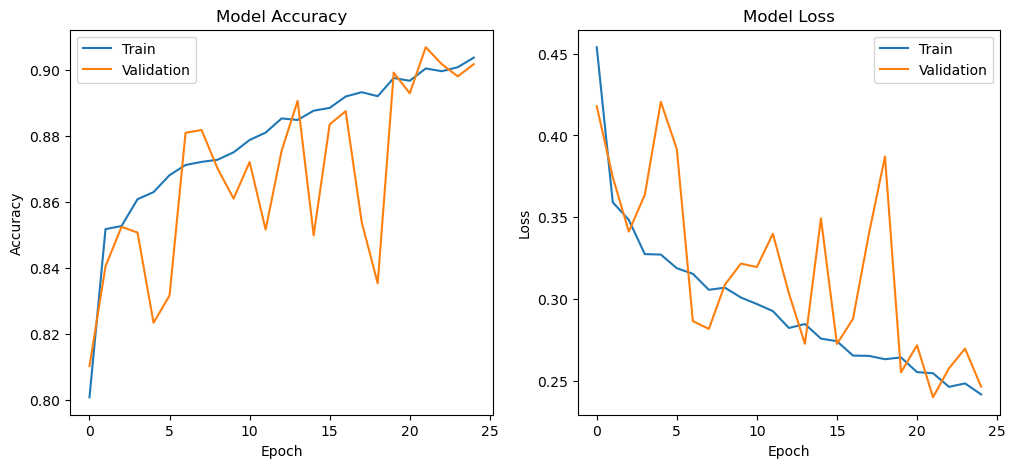

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"])

plt.show()


In [42]:
#Evaluate on Test Data

In [43]:
test_loss, test_acc = model.evaluate(test_data)
print("Test Accuracy:", test_acc)


208/208 ━━━━━━━━━━━━━━━━━━━━ 1226s 6s/step - accuracy: 0.8958 - loss: 0.2552
Test Accuracy: 0.8957894444465637


In [73]:
#model.save


In [45]:
model.save("cnn_obscene_detect.keras")


In [46]:
#Get predictions on test data

In [55]:
import numpy as np

# Get true labels
y_true = test_data.classes

# Get predicted probabilities
y_pred_prob = model.predict(test_data)

# Convert probabilities to class labels (0/1)
y_pred = (y_pred_prob > 0.40).astype(int).reshape(-1)


C:\Users\hp\anaconda3\Lib\site-packages\PIL\Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


208/208 ━━━━━━━━━━━━━━━━━━━━ 933s 4s/step


In [56]:
#Confusion Matrix

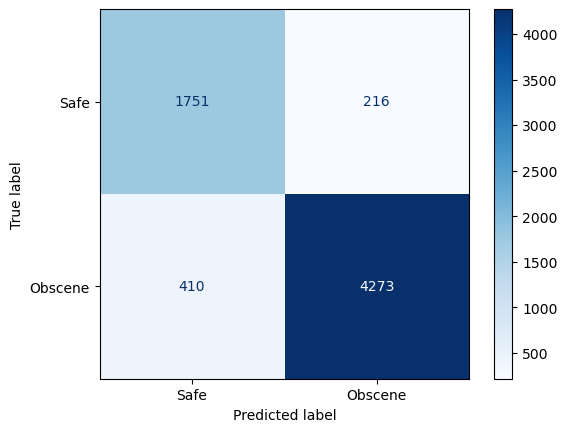

In [57]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Safe", "Obscene"]
)
disp.plot(cmap="Blues")


In [58]:
#Classification Report

In [60]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=["Safe", "Obscene"]
))

              precision    recall  f1-score   support

        Safe       0.81      0.89      0.85      1967
     Obscene       0.95      0.91      0.93      4683

    accuracy                           0.91      6650
   macro avg       0.88      0.90      0.89      6650
weighted avg       0.91      0.91      0.91      6650



In [61]:
#Prediction function

In [62]:
import os
from tensorflow.keras.preprocessing import image
import numpy as np

def predict_image(img_path):
    if not os.path.exists(img_path):
        print("❌ File not found:", img_path)
        return

    img = image.load_img(img_path, target_size=(224,224))
    img = image.img_to_array(img)
    img = img / 255.0
    img = np.expand_dims(img, axis=0)

    pred = model.predict(img)[0][0]

    print("Threshold score:", pred)

    # IMPORTANT: correct label logic
    if pred >= 0.45:
        print("✅ Safe Image")
    else:
        print("🚫 Obscene Image Detected")


In [63]:
#Test Image

In [64]:
predict_image("test_image/7721.jpg")


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 959ms/step
Threshold score: 0.04794033
🚫 Obscene Image Detected


In [65]:
predict_image("test_image/7336.jpg")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step
Threshold score: 0.0006190526
🚫 Obscene Image Detected


In [66]:
predict_image("test_image/7721.jpg")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step
Threshold score: 0.04794033
🚫 Obscene Image Detected


In [67]:
predict_image("dataset/test/obscene/5444.jpg")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step
Threshold score: 0.025165187
🚫 Obscene Image Detected


In [75]:
predict_image("test_image/7227.jpg")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 297ms/step
Threshold score: 0.23805913
🚫 Obscene Image Detected


In [ ]:
"C:\Users\hp\Downloads\pranay.jpeg"

In [79]:
predict_image(r"C:\Users\hp\Downloads\pranay.jpeg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 286ms/step
Threshold score: 0.027214885
🚫 Obscene Image Detected
